# Import 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from ase.build import bulk

In [3]:
from amstools import *

# AMStools: Atomic Modeling and Simulation Tools

Welcome to the AMStools tutorial! This notebook provides a comprehensive guide to using AMStools for advanced materials science simulations. 
AMStools is designed to integrate seamlessly with the Atomic Simulation Environment (ASE) and high-performance computing backends like LAMMPS.

### Key Features Covered:
*   **Property Calculations**: E-V curves, Elastic constants, Phonons, and Surface properties.
*   **Automated Pipelines**: Complex workflows with relaxation and property calculation steps.
*   **Advanced Analysis**: RDF, SRO, and trajectory analysis.


# 1. ASE calculator creation

AMStools requires **ASE-compatible** calculator to run.

NOTE: If your calculator/atoms use **magnetic moments** (i.e. by *atoms.get_initial_magnetic_moments*), then certain properties wouldn't be computed correctly!

Here are few common ways of creating ASE calculator:

## 1.1 LAMMPS

1. Compile LAMMPS with a support of desired potential. If you use **cmake**, then for example:
```
    mkdir build; cd build
    cmake -DCMAKE_BUILD_TYPE=Release -DPKG_MANYBODY=ON ../cmake
    cmake --build .
``` 
if you use **make**:
```
cd src
make yes-manybody
make serial
```
2. Specify the path to LAMMPS calcualtor, see [ASE/LAMMPSrun](https://wiki.fysik.dtu.dk/ase/ase/calculators/lammpsrun.html) for more details:

```python
import os
from ase.calculators.lammpsrun import LAMMPS

os.environ["ASE_LAMMPSRUN_COMMAND"]="/path/to/lmp_serial"

tmp_dir = os.path.join(os.getcwd(),"tmp")

kimpotential="EAM_Dynamo_Zhou_Johnson_Mo__MO_271256517527_002"
atom="Mo"
mass=20.18
    
cmds = {"pair_style": "kim LAMMPSvirial " + kimpotential,
        "pair_coeff": ["* * " + atom],
        "mass": ["1 " + str(mass)]}
calc = LAMMPS(parameters=cmds, keep_alive=False,tmp_dir=tmp_dir)
```

# 1.2 OpenKIM calculator

In order  add more ASE-compatible potentials for comparison into a testing framework one could use OpenKIM project and its API. Here are the steps:
1.  Install lib-kim following [these](https://openkim.org/doc/usage/obtaining-models/) instructions
2.  Install necessary or all potentials, i.e. `kim-api-collections-management install user SW_StillingerWeber_1985_Si__MO_405512056662_005`
3. Install `kimpy` as described [here](https://github.com/openkim/kimpy), i.e. `pip install kimpy`
4.  Use ASE interface to KIM calculator, as described [here](https://wiki.fysik.dtu.dk/ase/dev/ase/calculators/kim.html):

```python
from ase.calculators.kim.kim import KIM
calc = KIM("SW_StillingerWeber_1985_Si__MO_405512056662_005")
```

## 1.3 Custom calculators

One could use any other ASE compatible calculators, for example for **Atomic cluster expansion** (ACE):

```python
from pyace import PyACECalculator

calc = PyACECalculator("Cu.PBE.yaml")
```

## 1.4 ASE builtin calculators

There are plenty of ASE calculators, check [Calculators](https://wiki.fysik.dtu.dk/ase/ase/calculators/calculators.html) for a list

In [4]:
from ase.calculators.emt import EMT

calc=EMT()

## 1.5 Checking the calculator

To simply check the ASE calculator, you could create a simple structure, i.e. FCC-Cu and compute its energy:

In [5]:
from ase.build import bulk
struct = bulk('Cu', 'fcc')

set calculator

In [6]:
struct.calc = calc

In [7]:
struct.get_potential_energy()

np.float64(-0.005681511358581304)

If you see some number, then ASE calculator is working

# 2. AMS tools

## 2.1 Optimization

### 2.1.1 IsoOptimizer

Basic structural relaxation wrapper.

| Parameter | Type | Description | Default |
| :--- | :--- | :--- | :--- |
| `fmax` | `float` | Force convergence threshold (eV/Å). | `0.05` |
| `max_steps` | `int` | Maximum number of optimization steps. | `500` |
| `optimizer` | `str` | Name of the ASE optimizer to use (e.g., "BFGS", "FIRE"). | `"BFGS"` |

Optimize structure energy by *isotropically* changing the volume, using *scipy* optimization algorithms

In [8]:
optimizer=IsoOptimizer(struct)

In [9]:
optimized_structure = optimizer.run()

In [10]:
optimized_structure.get_potential_energy()

np.float64(-0.007036261551624179)

Other options:
* method='Nelder-Mead'

### 2.1.2 SpecialOptimizer

Advanced relaxation wrapper with DFT-specific optimization handling.

| Parameter | Type | Description | Default |
| :--- | :--- | :--- | :--- |
| `fmax` | `float` | Force convergence threshold (eV/Å). | `0.005` |
| `max_steps` | `int` | Maximum number of optimization steps. | `500` |
| `optimize_atoms_only` | `bool` | If `True`, only atomic positions are relaxed, cell remains fixed. | `False` |
| `optimizer` | `str` | Name of the ASE optimizer to use. | `"BFGS"` |

Wrapper around ASE optimizers. It uses BFGS, then FIRE and then MDMin consecutively, if the previous optimizer didn't succeed

Optimize only atoms

In [11]:
optimizer=SpecialOptimizer(struct, optimize_atoms_only=True)

In [12]:
optimized_structure = optimizer.run()

In [13]:
optimized_structure.get_potential_energy()

np.float64(-0.005681511358581304)

Optimize atoms and cell (default)

In [14]:
optimizer=SpecialOptimizer(struct)

In [15]:
optimized_structure = optimizer.run()

In [16]:
optimized_structure.get_potential_energy()

np.float64(-0.0070361227009314575)

Other options:
 * fmax=0.005
 * max_steps=500

### 2.1.3 StepwiseOptimizer

Sequential relaxation that iteratively performs:
1. Atomic-only optimization (fixed cell).
2. Cell-only optimization (fixed atoms).
3. Simultaneous optimization.

| Parameter | Type | Description | Default |
| :--- | :--- | :--- | :--- |
| `fmax` | `float` | Final force convergence threshold. | `0.05` |
| `dEmax` | `float` | Energy change convergence threshold. | `1e-3` |
| `max_steps` | `int` | Maximum steps per iteration. | `500` |
| `max_restart` | `int` | Maximum number of stepwise cycles. | `3` |
| `relative_volume_change_tolerance`| `float` | Volume convergence tolerance. | `1e-3` |

Simultaneous optimization of atomic positions and cell is ill-defined problem. **StepwiseOptimizer** iteratively performs two steps: 
1. atomic-only optimization with *SpecialOptimizer* using provided `fmax=1e-6` and `max_steps=500`
2. cell-only optimization using ASE's *StrainFilter* and *BFGS*

until energy change above `dEmax=1e-3` or `max_steps=500` is not reached

In [17]:
optimizer=StepwiseOptimizer(struct)

In [18]:
optimized_structure = optimizer.run()

In [19]:
optimized_structure.get_potential_energy()

np.float64(-0.007036261551624179)

## 2.2 Properties calculation

 All results of the calculations as well as input parameters are stored in a *JSON-friendly* dictionary variable, called `property_calculator.value` (`property_calculator.VALUE` or `property_calculator._VALUE`, are also valid names, point to the same dictionary)

### 2.2.1 Energy-nearest neighbour distance curves (NearestNeighboursExpansionCalculator)

Calculates the energy as a function of the nearest-neighbor distance (uniform scaling). Useful for mapping the range of interatomic potentials.

#### Available Parameters:

| Parameter | Type | Description | Default |
| :--- | :--- | :--- | :--- |
| `nn_distance_range` | `tuple` | Range of NN distances to sample (Å). | `(2, 5)` |
| `nn_distance_step` | `float` | Sampling step size (Å). | `0.05` |
| `num_of_point` | `int` | Total number of points (alternative to step). | `None` |
| `fix_kmesh` | `bool` | If `True`, keeps k-points constant despite volume changes. | `False` |

Calcualtion of E-NN distance curve and related quantities

    :param atoms: original ASE Atoms object
    :param num_of_point: number of points
    :param nn_distance_range: nearest neighbours distance deformation range, fraction, i.e. 0.1 (+/- 10%) or [nn_min, nn_max]
    :param nn_distance_step: NN distance step

In [20]:
e_nn_calculator = NearestNeighboursExpansionCalculator(optimized_structure, 
                                                  num_of_point=50, 
                                                  nn_distance_range=(2,5),
                                                  nn_distance_step=0.05
                                                 )

In [21]:
e_nn_calculator.calculate()

Results are stored in `.value` dictionary:

In [22]:
print(e_nn_calculator.value.keys())

odict_keys(['nn_distances', 'nn_distances_step', 'volumes', 'energy', 'stresses', 'volume', 'gradient', 'energy_min', 'energy_min_nn_dist'])


In [23]:
e_nn_calculator.value

OrderedDict([('nn_distances',
              array([2.        , 2.06122449, 2.12244898, 2.18367347, 2.24489796,
                     2.30612245, 2.36734694, 2.42857143, 2.48979592, 2.55102041,
                     2.6122449 , 2.67346939, 2.73469388, 2.79591837, 2.85714286,
                     2.91836735, 2.97959184, 3.04081633, 3.10204082, 3.16326531,
                     3.2244898 , 3.28571429, 3.34693878, 3.40816327, 3.46938776,
                     3.53061224, 3.59183673, 3.65306122, 3.71428571, 3.7755102 ,
                     3.83673469, 3.89795918, 3.95918367, 4.02040816, 4.08163265,
                     4.14285714, 4.20408163, 4.26530612, 4.32653061, 4.3877551 ,
                     4.44897959, 4.51020408, 4.57142857, 4.63265306, 4.69387755,
                     4.75510204, 4.81632653, 4.87755102, 4.93877551, 5.        ])),
             ('nn_distances_step', np.float64(0.06122448979591821)),
             ('volumes',
              [np.float64(5.6568542494923815),
               n

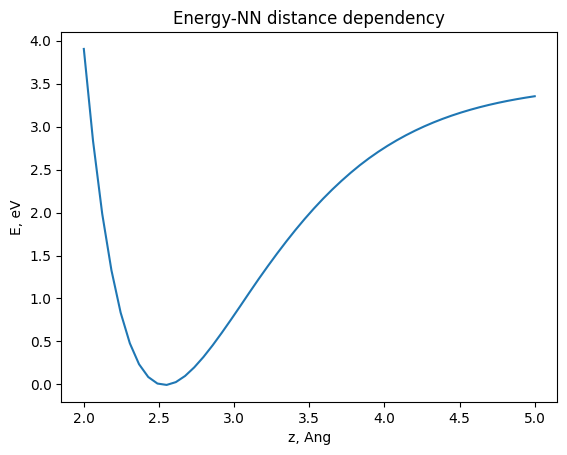

In [24]:
plt.title("Energy-NN distance dependency")
plt.plot(e_nn_calculator.value["nn_distances"],e_nn_calculator.value["energy"])
plt.xlabel("z, Ang")
plt.ylabel("E, eV");

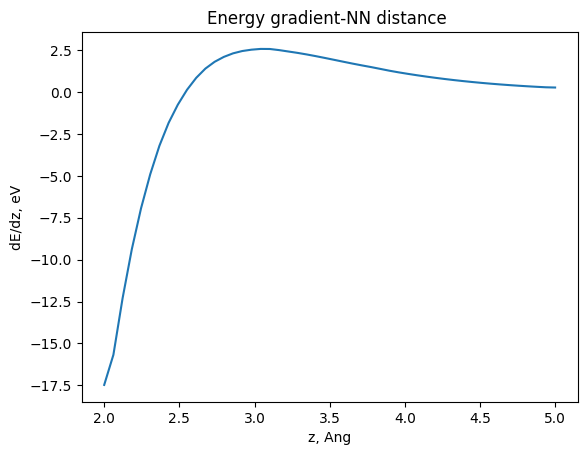

In [25]:
plt.title("Energy gradient-NN distance ")
plt.plot(e_nn_calculator.value["nn_distances"],e_nn_calculator.value["gradient"])
plt.xlabel("z, Ang")
plt.ylabel("dE/dz, eV");

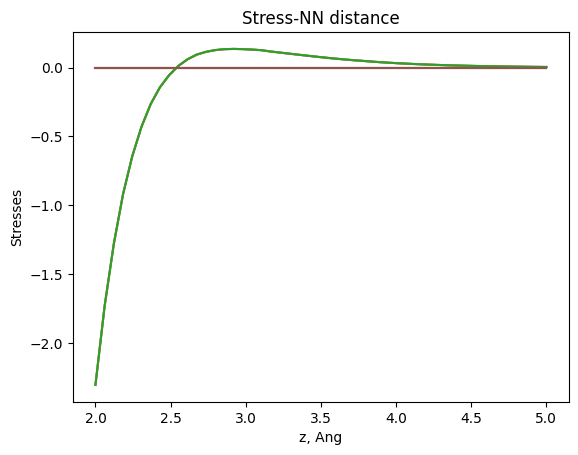

In [26]:
plt.title("Stress-NN distance")
plt.plot(e_nn_calculator.value["nn_distances"],e_nn_calculator.value["stresses"])
plt.xlabel("z, Ang")
plt.ylabel("Stresses");

or use `.plot` method

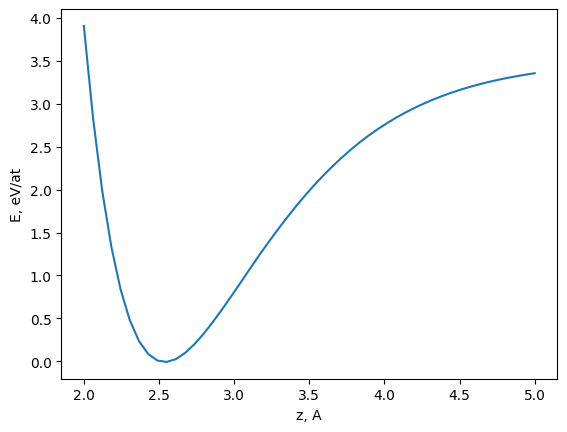

In [27]:
e_nn_calculator.plot()

### 2.2.2 Energy-Volume Curves (MurnaghanCalculator)

The Equation of State (EOS) is fundamental to understanding materials properties. 
The `MurnaghanCalculator` automates the process of calculating total energy at various volumes and fitting the results to extract equilibrium properties.

#### Available Parameters:

| Parameter | Type | Description | Default |
| :--- | :--- | :--- | :--- |
| `num_of_point` | `int` | Number of volume points to sample. | `11` |
| `volume_range` | `float` or `tuple` | Range of volume deformation (e.g., 0.1 for ±10%). | `0.1` |
| `fit_order` | `int` | Order of the polynomial fit for the E-V curve. | `5` |
| `optimize_deformed_structure` | `bool` | Relax internal coordinates at each volume point. | `False` |
| `optimizer` | `ASE Optimizer` | Optimizer to use if relaxation is enabled. | `BFGS` |
| `fmax` | `float` | Force convergence threshold (eV/Å). | `0.005` |
| `optimizer_kwargs` | `dict` | Additional settings for the optimizer. | `None` |

In [28]:
murn_calculator = MurnaghanCalculator(optimized_structure)

use calculate method. One can use `verbose = True` option for more details of calculations

In [29]:
murn_calculator.calculate(verbose=True)

2026-03-01 12:51:59,672 - root - INFO - Processing task/structure #1/11: strain_0_9
2026-03-01 12:51:59,679 - root - INFO - Processing task/structure #2/11: strain_0_92
2026-03-01 12:51:59,688 - root - INFO - Processing task/structure #3/11: strain_0_9400000000000001
2026-03-01 12:51:59,694 - root - INFO - Processing task/structure #4/11: strain_0_9600000000000001
2026-03-01 12:51:59,700 - root - INFO - Processing task/structure #5/11: strain_0_9800000000000001
2026-03-01 12:51:59,706 - root - INFO - Processing task/structure #6/11: strain_1_0
2026-03-01 12:51:59,712 - root - INFO - Processing task/structure #7/11: strain_1_02
2026-03-01 12:51:59,719 - root - INFO - Processing task/structure #8/11: strain_1_04
2026-03-01 12:51:59,724 - root - INFO - Processing task/structure #9/11: strain_1_06
2026-03-01 12:51:59,730 - root - INFO - Processing task/structure #10/11: strain_1_08
2026-03-01 12:51:59,736 - root - INFO - Processing task/structure #11/11: strain_1_1


available data:

In [30]:
murn_calculator.value

OrderedDict([('volume',
              array([10.40657771, 10.63783499, 10.86909227, 11.10034956, 11.33160684,
                     11.56286412, 11.7941214 , 12.02537869, 12.25663597, 12.48789325,
                     12.71915053])),
             ('energy',
              array([ 0.05118334,  0.02896533,  0.01253652,  0.00138716, -0.00498187,
                     -0.00703626, -0.00520159,  0.00013658,  0.0086309 ,  0.01997057,
                      0.03388057])),
             ('pressure',
              array([ 0.10930185,  0.08319525,  0.05925809,  0.037527  ,  0.01789081,
                      0.00018298, -0.01577217, -0.03014414, -0.04309401, -0.05477752,
                     -0.06534881])),
             ('equilibrium_energy', np.float64(-0.007038484285217805)),
             ('equilibrium_volume', np.float64(11.565316606307942)),
             ('equilibrium_bulk_modulus', np.float64(134.5835463062698)),
             ('equilibrium_b_prime', np.float64(4.240432463949352)),
             ('

* 'volume' - list of volumes
* 'energy' - list of energies
* 'equilibrium_energy'
* 'equilibrium_volume'
* 'equilibrium_bulk_modulus'
* 'equilibrium_b_prime'
* 'energy_rms'

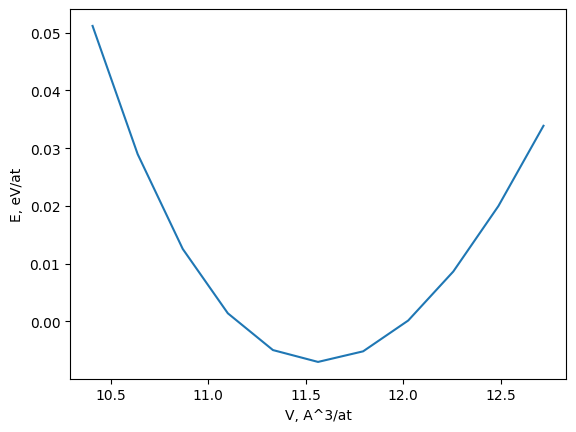

In [31]:
murn_calculator.plot()

get structure with predicted equilibrium volume

In [32]:
final_struct = murn_calculator.get_final_structure()

In [33]:
final_struct

Atoms(symbols='Cu', pbc=True, cell=[[7.304300194890666e-18, 1.794909310021374, 1.7949093100213749], [1.7949093100213749, -6.53383192426823e-18, 1.7949093100213749], [1.7949093100213749, 1.794909310021374, 1.0608988010254433e-17]], calculator=EMT(...))

### 2.2.3 Elastic matrix (ElasticMatrixCalculator)

Calculation of the second-order elastic stiffness matrix ($C_{ij}$) and derived mechanical properties (Bulk, Shear, Young's moduli).

#### Available Parameters:

| Parameter | Type | Description | Default |
| :--- | :--- | :--- | :--- |
| `num_of_point` | `int` | Number of strain points per deformation direction. | `5` |
| `eps_range` | `float` | Maximum strain amplitude. | `0.005` |
| `sqrt_eta` | `bool` | Use the Lagrangian strain definition $\eta$. | `True` |
| `fit_order` | `int` | Polynomial order for energy-strain fitting. | `2` |
| `optimize_deformed_structure` | `bool` | Relax atoms at each applied strain. | `True` |
| `optimizer` | `ASE Optimizer` | Optimizer class. | `BFGS` |
| `fmax` | `float` | Force convergence (eV/Å). | `0.005` |
| `ignore_symmetry` | `bool` | Skip symmetry detection (applies more deformations). | `False` |
| `optimizer_kwargs` | `dict` | Additional optimizer arguments. | `None` |


    
Reference: 
* ```
R. Golesorkhtabar, P. Pavone, J. Spitaler, P. Puschnig, and C. Draxl,  
    ElaStic: A tool for calculating second-order elastic constants from first principles,
    Comp. Phys. Commun. 184, 1861 (2013)
```
    
* ElaStic source code (http://exciting-code.org/elastic)    
    

In [34]:
elmat = ElasticMatrixCalculator(final_struct)

In [35]:
elmat.calculate()

available data:

* 'SGN' - space group number
* 'v0' - volume of undeformed structure
* 'LC' - symmetry class
* 'Lag_strain_list'  - list of deformation types
* 'epss' - list of deformation range
* 'e0' - energy of undeformed structure
* 'strain_energy' - list of pairs (epsilon, energy) for all deformation types
* 'C' - elastic matrix
* 'C_eigval' - eigenvalues and eigenvectors of elastic matrix
* 'S' - inverse elastic matrix
* 'A2' - quadratic coefficient of strain-energy curves
* 'A1' - linear  coefficient of strain-energy curves
* 'energy_rms' - RMS of strain-energy curves fitting
* 'BV', 'GV',  'EV',   'nuV' - bulk, shear and Young modulus in Voigt approximation
* 'BR', 'GR', 'ER', 'nuR' - bulk, shear and Young modulus in Reuss approximation
* 'BH', 'GH', 'EH', 'nuH' - bulk, shear and Young modulus in Hill approximation 

In [36]:
elmat.value.keys()

odict_keys(['ignore_symmetry', 'space_group_number', 'v0', 'laue_group', 'strain_list', 'epss', 'e0', 'strain_energy', 'C', 'A2', 'energy_rms', 'A1', 'C_std', 'BV', 'GV', 'EV', 'nuV', 'S', 'BR', 'GR', 'ER', 'nuR', 'BH', 'GH', 'EH', 'nuH', 'AVR', 'C_eigval'])

In [37]:
elmat.value

OrderedDict([('ignore_symmetry', False),
             ('space_group_number', 225),
             ('v0', np.float64(11.565316606307942)),
             ('laue_group', 'CI'),
             ('strain_list', [1, 8, 23]),
             ('epss', array([-0.005 , -0.0025,  0.    ,  0.0025,  0.005 ])),
             ('e0', np.float64(-0.007036491886934115)),
             ('strain_energy',
              [[(np.float64(-0.005), np.float64(-0.005920206773465608)),
                (np.float64(-0.0025), np.float64(-0.006760144255608225)),
                (np.float64(0.0), np.float64(-0.007036491886934115)),
                (np.float64(0.0024999999999999996),
                 np.float64(-0.006766746408585433)),
                (np.float64(0.005), np.float64(-0.005967932393296849))],
               [(np.float64(-0.005), np.float64(-0.006505856621121353)),
                (np.float64(-0.0025), np.float64(-0.0069049883172755955)),
                (np.float64(0.0), np.float64(-0.007036491886934115)),
          

Elastic matrix, $C_{ij}, i=1..6, j=1..6$

In [38]:
elmat.value["C"]

array([[172.64045192, 115.46788123, 115.46788123,   0.        ,
          0.        ,   0.        ],
       [115.46788123, 172.64045192, 115.46788123,   0.        ,
          0.        ,   0.        ],
       [115.46788123, 115.46788123, 172.64045192,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ,  89.96832361,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ,   0.        ,
         89.96832361,   0.        ],
       [  0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,  89.96832361]])

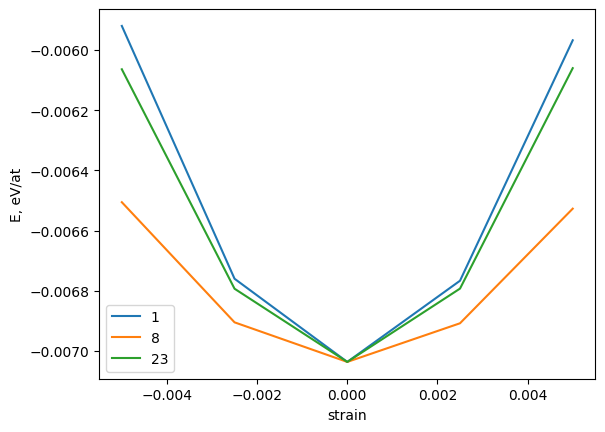

In [39]:
elmat.plot()

### 2.2.4 Phonons (PhonopyCalculator)

Lattice vibrations (phonons) determine thermal properties and phase stability. 
AMStools uses the powerful `phonopy` library as a backend to perform finite-displacement calculations.

#### Available Parameters:

| Parameter | Type | Description | Default |
| :--- | :--- | :--- | :--- |
| `interaction_range` | `float` | Cutoff for force constants (determines supercell size). | `10.0` |
| `supercell_range` | `tuple` | Explicit supercell matrix (optional). | `None` |
| `displacement` | `float` | Atomic displacement amplitude for finite differences (Å). | `0.01` |
| `q_mesh` | `int` or `list` | Sampling mesh for DOS/thermal properties. | `75` |
| `q_mesh_spacing` | `float` | Mesh spacing instead of fixed number. | `None` |
| `is_symmetry` | `bool` | Use symmetry for displacement reduction. | `True` |

Phonons calculations are done using [`phonopy`](https://phonopy.github.io/phonopy/) backend.

Reference:
* “First principles phonon calculations in materials science”,Atsushi Togo and Isao Tanaka, Scr. Mater., 108, 1-5 (2015)

In [40]:
phonon_calculator = PhonopyCalculator(final_struct)

In [41]:
phonon_calculator.calculate()

In [42]:
print(phonon_calculator.VALUE.keys())

odict_keys(['phonopy_data', 'dos_total', 'dos_energies'])


/var/folders/pr/lf8m5byn1bn768g7hzn6yn3c0000gn/T/ipykernel_19436/3583240197.py:1: DeprecationWarning: Accessing .VALUE is deprecated. Please use .value instead.
  print(phonon_calculator.VALUE.keys())


* dos_energies and dos_total are (X,Y) coordinates for phonon density of state plot

/var/folders/pr/lf8m5byn1bn768g7hzn6yn3c0000gn/T/ipykernel_19436/814039183.py:1: DeprecationWarning: Accessing .VALUE is deprecated. Please use .value instead.
  plt.plot(phonon_calculator.VALUE["dos_energies"], phonon_calculator.VALUE["dos_total"])


Text(0, 0.5, 'Phonon DOS, THz$^{-1}$')

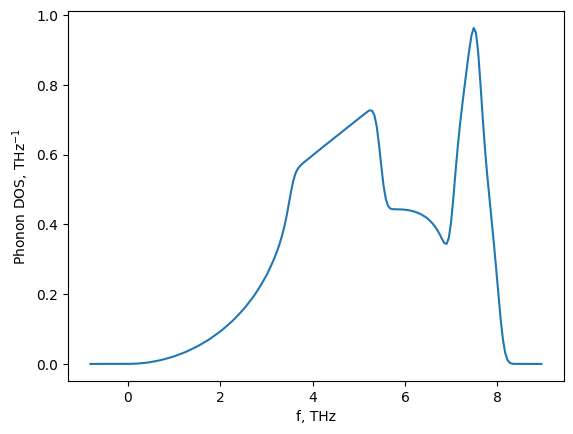

In [43]:
plt.plot(phonon_calculator.VALUE["dos_energies"], phonon_calculator.VALUE["dos_total"])
plt.xlabel("f, THz")
plt.ylabel("Phonon DOS, THz$^{-1}$")

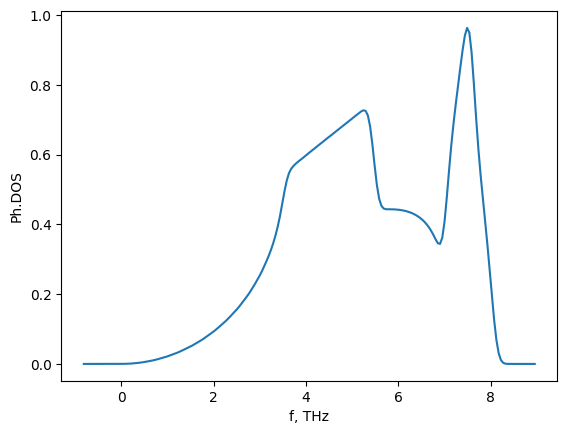

In [44]:
phonon_calculator.plot()

**Phonon calculator** has some phonon DOS and band structure (dispersion) customizable plotting functions:

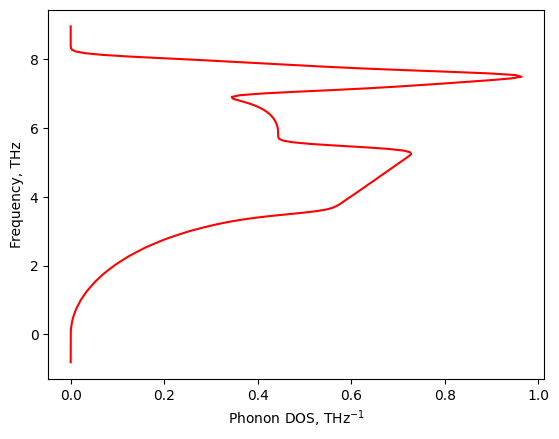

In [45]:
phonon_calculator.plot_total_DOS(flip_xy=True)

Provide path in BZ for dispersion calculations and plotting:

In [46]:
path = [[[0, 0, 0], [0.5, 0, 0.5], [0.625, 0.25, 0.625],
        [0.375, 0.375, 0.75], [0, 0, 0], [0.5, 0.5, 0.5], [0.5, 0.25, 0.75]]]
labels = ["G", "X", "U", "K", "G", "L", "W"]

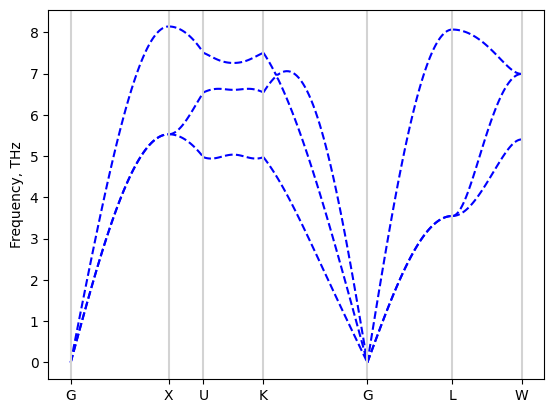

In [47]:
phonon_calculator.plot_band_structure(path, labels, plot_kwargs={"color":"blue","ls":"--"})

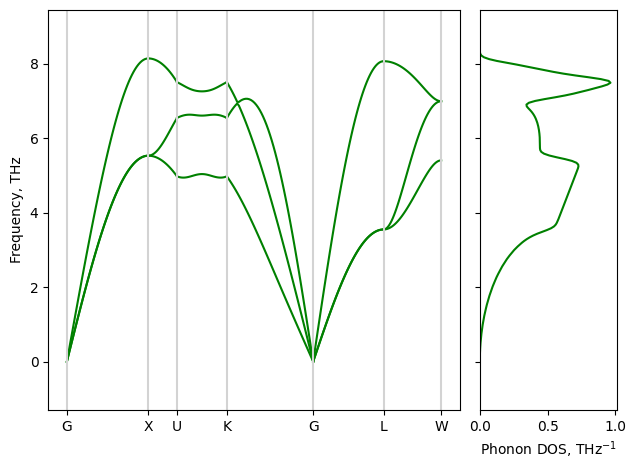

In [48]:
phonon_calculator.plot_band_structure_and_dos(path, labels, plot_kwargs={"color":"green"})

One could get `phonopy` object for more advanced manipulations with phonopy data.
See [Phonopy API for Python](https://phonopy.github.io/phonopy/phonopy-module.html) for more details

In [49]:
phonon = phonon_calculator.phonopy

<module 'matplotlib.pyplot' from '/Users/lysogy36/micromamba/envs/grace/lib/python3.11/site-packages/matplotlib/pyplot.py'>

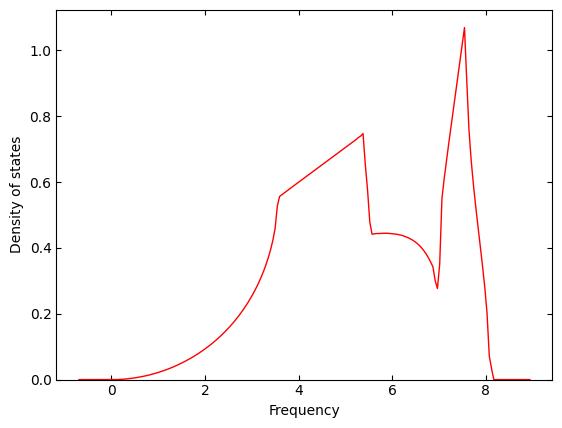

In [50]:
phonon.run_mesh([50,50,50])
phonon.run_total_dos()
phonon.plot_total_dos()

For example, phonon dispersion and eigenvectors calculation:

In [51]:
from phonopy.phonon.band_structure import get_band_qpoints_and_path_connections
qpoints, connections = get_band_qpoints_and_path_connections(path, npoints=51)

In [52]:
phonon.run_band_structure(qpoints, path_connections=connections, labels=labels, with_eigenvectors=True)

In [53]:
band_structure_dict= phonon.get_band_structure_dict()

In [54]:
band_structure_dict.keys()

dict_keys(['qpoints', 'distances', 'frequencies', 'eigenvectors', 'group_velocities'])

In [55]:
q_points=band_structure_dict['qpoints']
distances=band_structure_dict['distances']
frequencies=band_structure_dict['frequencies']
eigenvectors=band_structure_dict['eigenvectors']

In [56]:
eigenvectors[0].shape

(51, 3, 3)

Eigenvectors at gamma point:

In [57]:
eigenvectors[0][0]

array([[-3.87728493e-03-0.j,  1.81460924e-04+0.j, -9.99992467e-01+0.j],
       [ 9.89355031e-01+0.j,  1.45472023e-01+0.j, -3.80964256e-03+0.j],
       [-1.45470236e-01-0.j,  9.89362349e-01+0.j,  7.43565761e-04+0.j]])

### 2.2.5 Transformation paths (TransformationPathCalculator)

Evaluates the energy landscape along structural transformation paths (e.g., Bain path between BCC and FCC).

#### Available Parameters:

| Parameter | Type | Description | Default |
| :--- | :--- | :--- | :--- |
| `transformation_type` | `str` | Type of path ("tetragonal", "orthorhombic", "trigonal", "hexagonal", "general_cubic_tetragonal"). | `"tetragonal"` |
| `num_of_point` | `int` | Number of points along the path. | `50` |

In [58]:
transpath_calculator=TransformationPathCalculator(final_struct, transformation_type="tetragonal")

In [59]:
transpath_calculator.calculate()

In [60]:
transpath_calculator.value.keys()

odict_keys(['transformation_type', 'transformation_coordinates', 'energies', 'n_at', 'energies_0'])

available data:
* 'transformation_coordinates' 
* 'energies_0' - energies of unrelaxed deformed structure with two atoms
* 'transformation_type' - transformation type

In [61]:
transpath_calculator.value

OrderedDict([('transformation_type', 'tetragonal'),
             ('transformation_coordinates',
              array([0.8       , 0.8244898 , 0.84897959, 0.87346939, 0.89795918,
                     0.92244898, 0.94693878, 0.97142857, 0.99591837, 1.02040816,
                     1.04489796, 1.06938776, 1.09387755, 1.11836735, 1.14285714,
                     1.16734694, 1.19183673, 1.21632653, 1.24081633, 1.26530612,
                     1.28979592, 1.31428571, 1.33877551, 1.36326531, 1.3877551 ,
                     1.4122449 , 1.43673469, 1.46122449, 1.48571429, 1.51020408,
                     1.53469388, 1.55918367, 1.58367347, 1.60816327, 1.63265306,
                     1.65714286, 1.68163265, 1.70612245, 1.73061224, 1.75510204,
                     1.77959184, 1.80408163, 1.82857143, 1.85306122, 1.87755102,
                     1.90204082, 1.92653061, 1.95102041, 1.9755102 , 2.        ])),
             ('energies',
              array([ 1.24445129e-01,  9.25232501e-02,  7.2409226

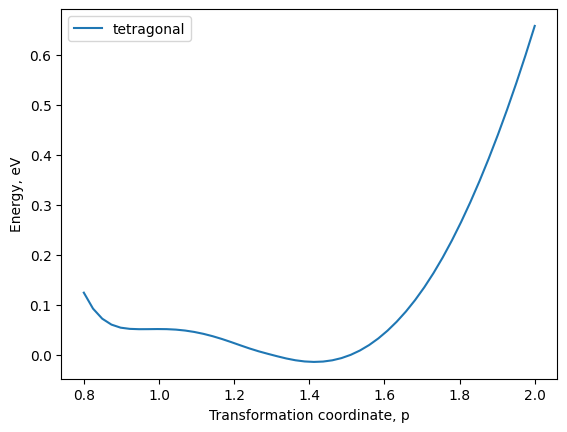

In [62]:
transpath_calculator.plot()
plt.legend()

Text(0.5, 1.0, 'Transformation path:tetragonal')

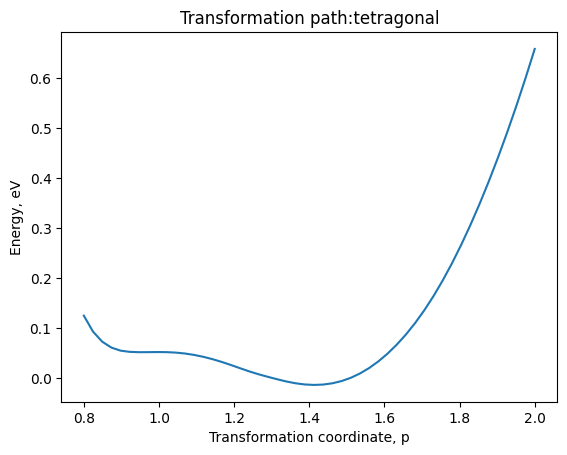

In [63]:
plt.plot(transpath_calculator.value["transformation_coordinates"],transpath_calculator.value["energies_0"])
plt.xlabel("Transformation coordinate, p")
plt.ylabel("Energy, eV")
plt.title("Transformation path:"+transpath_calculator.value["transformation_type"])

### 2.2.6 Vacancy formation energy (DefectFormationCalculator)

Calculates the energy required to create a vacancy by removing an atom from the lattice.

#### Available Parameters:

| Parameter | Type | Description | Default |
| :--- | :--- | :--- | :--- |
| `interaction_range` | `float` | Supercell size (Å). | `10.0` |
| `defect_type` | `str` | Type of defect (only "vacancy" supported here). | `"vacancy"` |
| `optimizer` | `ASE Optimizer` | Optimizer for structural relaxation. | `BFGS` |
| `fmax` | `float` | Force convergence threshold (eV/Å). | `0.05` |
| `optimizer_kwargs` | `dict` | Additional settings for the optimizer. | `None` |

In [64]:
vacancy_calculator = DefectFormationCalculator(final_struct)

In [65]:
vacancy_calculator.calculate()

ase.spacegroup.symmetrize: prec 0.01 got symmetry group number 225 , international (Hermann-Mauguin) Fm-3m , Hall  -F 4 2 3
ase.spacegroup.symmetrize: prec 0.01 got symmetry group number 225 , international (Hermann-Mauguin) Fm-3m , Hall  -F 4 2 3
ase.spacegroup.symmetrize: prec 0.0001 got symmetry group number 225 , international (Hermann-Mauguin) Fm-3m , Hall  -F 4 2 3
ase.spacegroup.symmetrize: prec 0.01 got symmetry group number 225 , international (Hermann-Mauguin) Fm-3m , Hall  -F 4 2 3
ase.spacegroup.symmetrize: prec 0.01 got symmetry group number 225 , international (Hermann-Mauguin) Fm-3m , Hall  -F 4 2 3
ase.spacegroup.symmetrize: prec 0.01 got symmetry group number 225 , international (Hermann-Mauguin) Fm-3m , Hall  -F 4 2 3
ase.spacegroup.symmetrize: prec 0.0001 got symmetry group number 225 , international (Hermann-Mauguin) Fm-3m , Hall  -F 4 2 3
ase.spacegroup.symmetrize: prec 0.01 got symmetry group number 225 , international (Hermann-Mauguin) Fm-3m , Hall  -F 4 2 3


In [66]:
vacancy_calculator.value.keys()

odict_keys(['supercell_range', 'n', 'wyckoff_unique_indices', 'energies', 'volumes', 'vacancy_formation_energy', 'vacancy_formation_volume'])

available data:

* 'supercell_range' - supercell size
* 'n' - number of atoms on supercell
* 'wyckoff_unique_indices' - different wyckoff indices
* 'energies' - energies of structures:
    * supercell_0 - energy of big supercell
    * supercell_defect_wyck_a_static - energy of structure with vacancy at 'a' wyckoff site, no relaxation
    * supercell_defect_wyck_a_atomic - energy of structure with vacancy at 'a' wyckoff site, only atomic positions relaxed
    * supercell_defect_wyck_a_total - energy of structure with vacancy at 'a' wyckoff site, full relaxation
    
* 'volumes' - volumes of structures
* 'vacancy_formation_energy' - formation energy for vacancy in static, atomic and total approximations (see supercell description)
* 'vacancy_formation_volume' - - formation volume for vacancy

In [67]:
vacancy_calculator.value

OrderedDict([('supercell_range', [4, 4, 4]),
             ('n', 64),
             ('wyckoff_unique_indices', {'a': 0}),
             ('energies',
              {'supercell_0': np.float64(-0.450335480763421),
               'supercell_defect_wyck_a_static': np.float64(0.7950799201710197),
               'supercell_defect_wyck_a_atomic': np.float64(0.7829270836312681),
               'supercell_defect_wyck_a_total': np.float64(0.7819040876705472)}),
             ('volumes',
              {'supercell_0': np.float64(740.1802628037087),
               'supercell_defect_wyck_a_static': np.float64(740.1802628037087),
               'supercell_defect_wyck_a_atomic': np.float64(740.1802628037087),
               'supercell_defect_wyck_a_total': np.float64(738.8233258771554)}),
             ('vacancy_formation_energy',
              {'a_static': np.float64(1.2383789090475124),
               'a_atomic': np.float64(1.2262260725077607),
               'a_total': np.float64(1.2252030765470399)}),
 

In [68]:
print("Relaxed vacancy formation energy:", vacancy_calculator.value["vacancy_formation_energy"]["a_total"], " eV")

Relaxed vacancy formation energy: 1.2252030765470399  eV


### 2.2.7 Interstitial formation energy (InterstitialFormationCalculator)

Calculates the energy required to insert an extra atom into various interstitial sites (Octahedral, Tetrahedral).

#### Available Parameters:

| Parameter | Type | Description | Default |
| :--- | :--- | :--- | :--- |
| `interaction_range` | `float` | Supercell size (Å). | `10.0` |
| `interstitial_type` | `str` | "all", or specific sites like "octa", "tetra". | `"all"` |
| `optimizer` | `ASE Optimizer` | Optimizer for structural relaxation. | `FIRE` |
| `fix_symmetry` | `bool` | Preserve site symmetry during relaxation. | `True` |

In [69]:
interstitial_calculator = InterstitialFormationCalculator(final_struct)

In [70]:
interstitial_calculator.calculate()

ase.spacegroup.symmetrize: prec 0.01 got symmetry group number 123 , international (Hermann-Mauguin) P4/mmm , Hall  -P 4 2
ase.spacegroup.symmetrize: prec 0.01 got symmetry group number 123 , international (Hermann-Mauguin) P4/mmm , Hall  -P 4 2
ase.spacegroup.symmetrize: prec 0.0001 got symmetry group number 123 , international (Hermann-Mauguin) P4/mmm , Hall  -P 4 2
ase.spacegroup.symmetrize: prec 0.01 got symmetry group number 123 , international (Hermann-Mauguin) P4/mmm , Hall  -P 4 2
ase.spacegroup.symmetrize: prec 0.01 got symmetry group number 221 , international (Hermann-Mauguin) Pm-3m , Hall  -P 4 2 3
ase.spacegroup.symmetrize: prec 0.01 got symmetry group number 221 , international (Hermann-Mauguin) Pm-3m , Hall  -P 4 2 3
ase.spacegroup.symmetrize: prec 0.0001 got symmetry group number 221 , international (Hermann-Mauguin) Pm-3m , Hall  -P 4 2 3
ase.spacegroup.symmetrize: prec 0.01 got symmetry group number 221 , international (Hermann-Mauguin) Pm-3m , Hall  -P 4 2 3
ase.spac

Available computed properties

In [71]:
interstitial_calculator.value.keys()

odict_keys(['spgn', 'structure_type', 'lattice_param', 'supercell_size', 'ideal_structure_n_at', 'interstitial_type', 'structure_names', 'raw_data', 'interstitial_formation_energy'])

In [72]:
interstitial_calculator.value

OrderedDict([('spgn', 225),
             ('structure_type', 'fcc'),
             ('lattice_param', np.float64(3.5898186200427484)),
             ('supercell_size', 4),
             ('ideal_structure_n_at', 64),
             ('interstitial_type', ['100_dumbbell', 'octa', 'tetra']),
             ('structure_names',
              ['fcc_100_dumbbell_444', 'fcc_octa_444', 'fcc_tetra_444']),
             ('raw_data',
              {'IDEAL___static': {'energy': np.float64(-0.450335480763421),
                'max_force': np.float64(2.5671558779305894e-14),
                'volume': np.float64(740.1802628037087),
                'n_at': 64},
               'fcc_100_dumbbell_444___static': {'energy': np.float64(7.801793954733839),
                'max_force': np.float64(5.056285308846631),
                'volume': np.float64(2960.72105121483),
                'n_at': 257},
               'fcc_100_dumbbell_444___atomic': {'energy': np.float64(1.6973583154620293),
                'max_force': np

Interstitial formation energies for *static* (non-relaxed) and *atomic* (atomic only relaxed) structures, in eV:

In [73]:
interstitial_calculator.value["interstitial_formation_energy"]

{'fcc_100_dumbbell_444': {'static': np.float64(9.610172369674451),
  'atomic': np.float64(3.5057367304026417)},
 'fcc_octa_444': {'static': np.float64(15.732485716843392),
  'atomic': np.float64(3.712524228617253)},
 'fcc_tetra_444': {'static': np.float64(30.96146265480627),
  'atomic': np.float64(4.081971119167633)}}

### 2.2.8 Thermodynamic Quasiharmonic approximation (ThermodynamicQHACalculator)

Calculates temperature-dependent thermodynamic properties (Heat capacity, Free energy, Entropy) in the Quasiharmonic Approximation (QHA).

#### Available Parameters:

| Parameter | Type | Description | Default |
| :--- | :--- | :--- | :--- |
| `interaction_range` | `float` | Phonon supercell range. | `10.0` |
| `volume_range` | `float` | Range of volume sampling for QHA fit. | `0.1` |
| `tmin`, `tmax` | `tuple` | Temperature range (K). | `(1, 3000)` |
| `q_space_sample` | `int` | Q-mesh size. | `75` |
| `imaginary_phonons_fraction_threshold` | `float` | Threshold to skip structures with unstable modes. | `0.01` |
| `displacement` | `float` | Displacement for phonons. | `0.01` |

Calculation of thermodynamic quantities in quasiharmonic approximation

    :param atoms: original ASE Atoms object with calculator
    :param interaction_range: supercell size (default is 10 A)
    :param supercell_range:  supercell range (optional). If specified, interaction_range is ignored
    :param displacement: atom displacement from original position, in angstroms (default is 0.01)
    :param imaginary_phonons_fraction_threshold: maximum fraction of DOS with imaginary frequencies (default = 0.01)
    :param  murnaghan: MurnaghanCalculator, default - None, E-V curve would be computed
    :param volume_range: default=0.1, volume range for E-V curve
    :param fit_order: default=5, polynomial fit order for E-V curve
    :param num_of_point: default=11, number of points in E-V curve
    :param q_space_sample: default=75, q-mesh size for computing/integrating phonon DOS
    :param tmin, tmax: default=(1,3000) temperature range to compute thermodynamic properties

provide final structure of Murnaghan calculation. 
If no murnaghan data were provided, then it will be calculated

In [74]:
tqha = ThermodynamicQHACalculator(final_struct, murnaghan=murn_calculator)

use `verbose=True` flag to see the progress of calculations

In [75]:
tqha.calculate(verbose=True)

2026-03-01 12:52:09,204 - root - INFO - Processing task/structure #1/11: phonopy_vol_0
2026-03-01 12:52:09,787 - root - INFO - Processing task/structure #1/1: supercell_phonon_0
2026-03-01 12:52:10,398 - root - INFO - Processing task/structure #2/11: phonopy_vol_1
2026-03-01 12:52:10,938 - root - INFO - Processing task/structure #1/1: supercell_phonon_0
2026-03-01 12:52:11,579 - root - INFO - Processing task/structure #3/11: phonopy_vol_2
2026-03-01 12:52:12,119 - root - INFO - Processing task/structure #1/1: supercell_phonon_0
2026-03-01 12:52:12,732 - root - INFO - Processing task/structure #4/11: phonopy_vol_3
2026-03-01 12:52:13,301 - root - INFO - Processing task/structure #1/1: supercell_phonon_0
2026-03-01 12:52:13,910 - root - INFO - Processing task/structure #5/11: phonopy_vol_4
2026-03-01 12:52:14,449 - root - INFO - Processing task/structure #1/1: supercell_phonon_0
2026-03-01 12:52:15,089 - root - INFO - Processing task/structure #6/11: phonopy_vol_5
2026-03-01 12:52:15,629

Volume= 10.406577710066378  imag.frequencies fraction =  1.7617795641945095e-06
Volume= 10.637834992512294  imag.frequencies fraction =  1.6382617738477148e-06
Volume= 10.869092274958216  imag.frequencies fraction =  1.5787293347271802e-06
Volume= 11.10034955740414  imag.frequencies fraction =  1.5444658723752511e-06
Volume= 11.331606839850055  imag.frequencies fraction =  1.5179707777298884e-06
Volume= 11.562864122295975  imag.frequencies fraction =  1.493917355615383e-06
Volume= 11.794121404741896  imag.frequencies fraction =  1.4698887184369922e-06
Volume= 12.025378687187818  imag.frequencies fraction =  1.4445828348978262e-06
Volume= 12.256635969633733  imag.frequencies fraction =  1.416901678914068e-06
Volume= 12.487893252079651  imag.frequencies fraction =  1.3853208046983706e-06
Volume= 12.719150534525578  imag.frequencies fraction =  1.3485456776068086e-06


Basic contribution to energy is electronic contribution ( from Murnaghan calculation)

Text(0.5, 0, 'E, eV')

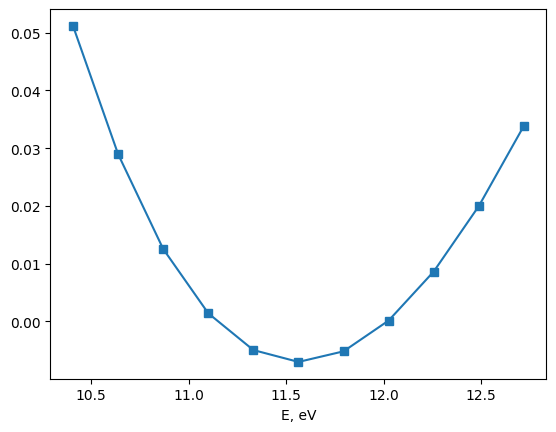

In [76]:
plt.plot(tqha.value["volume"],tqha.value["energy"],marker="s")
plt.xlabel("V, $\AA^3$")
plt.xlabel("E, eV")

Phonon DOS are used for calculation of Helmholz free energy F(T) at different volumes:

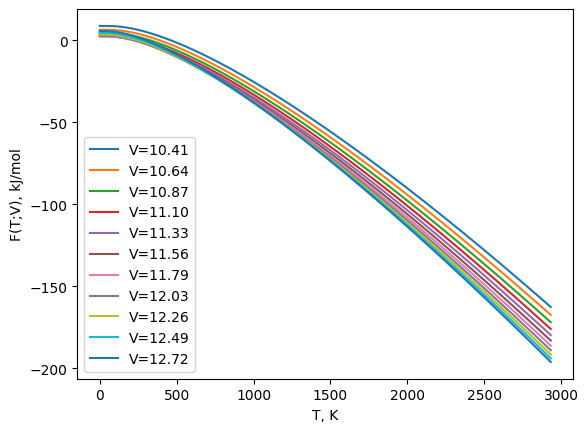

In [77]:
for vol,f_t in zip(tqha.volumes,tqha.F_V_T):
    plt.plot(tqha.temperatures,f_t,label="V=%.2f"%vol)
plt.legend()
plt.xlabel("T, K");
plt.ylabel("F(T;V), kJ/mol");

Gibbs free energy at P=0:

G(T,P=0) = min$_V$ F(V,T)

Text(0, 0.5, 'G, kJ/mol')

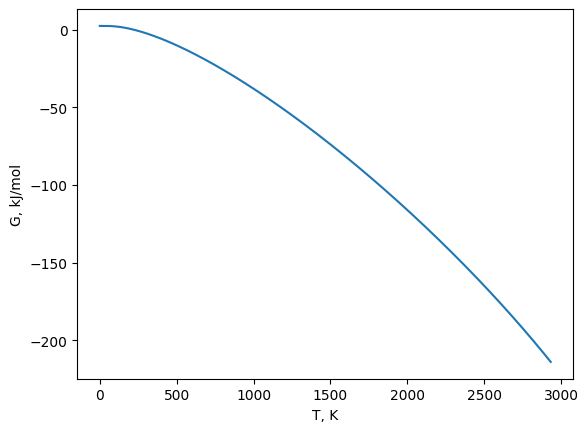

In [78]:
plt.plot(tqha.value["G_QHA"][0],tqha.value["G_QHA"][1])
plt.xlabel("T, K")
plt.ylabel("G, kJ/mol")

Equilibrium volume:

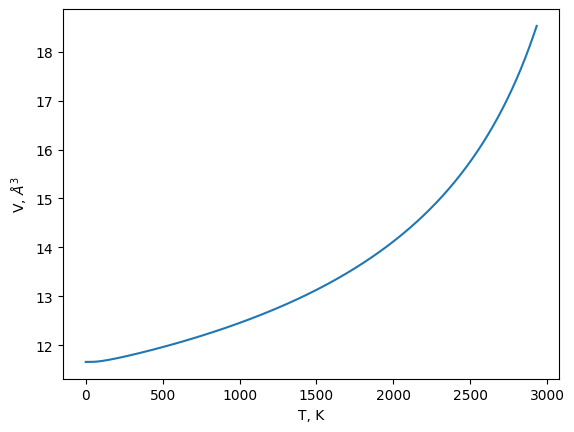

In [79]:
plt.plot(tqha.value["V_QHA"][0],tqha.value["V_QHA"][1])
plt.xlabel("T, K")
plt.ylabel("V, $\AA^3$");

Thermal volume expansion:

$\beta = \frac{1}{V} \frac{dV}{dT}$

Text(0, 0.5, '$\\beta \\times 10^6$, 1/K')

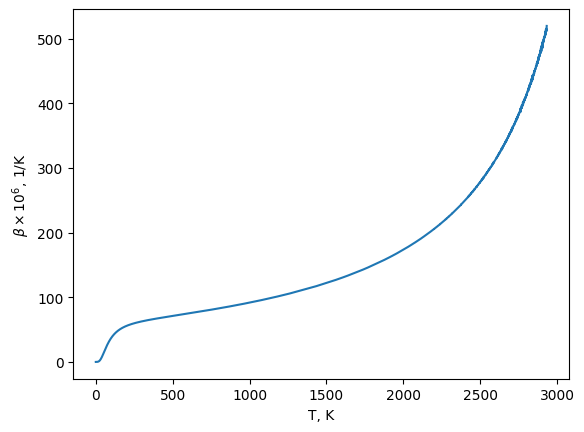

In [80]:
plt.plot(tqha.value["beta_QHA"][0],tqha.value["beta_QHA"][1]*1e6)
plt.xlabel("T, K")
plt.ylabel("$\\beta \\times 10^6$, 1/K")

Bulk modulus:

Text(0, 0.5, 'B, GPa')

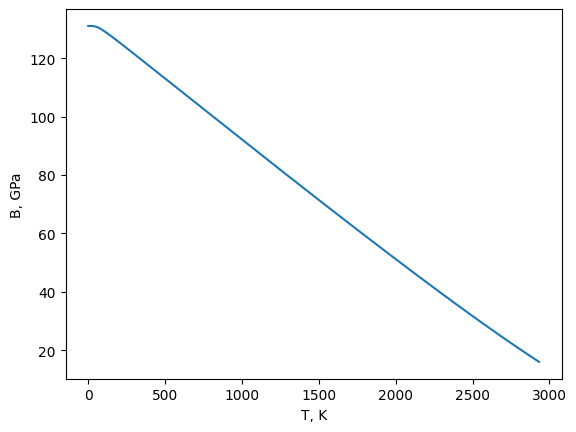

In [81]:
plt.plot(tqha.value["B_QHA"][0],tqha.value["B_QHA"][1])
plt.xlabel("T, K")
plt.ylabel("B, GPa")

Heat capacity
$C_P(T) = T \frac{d^2G}{dT^2}$

(0.0, 40.0)

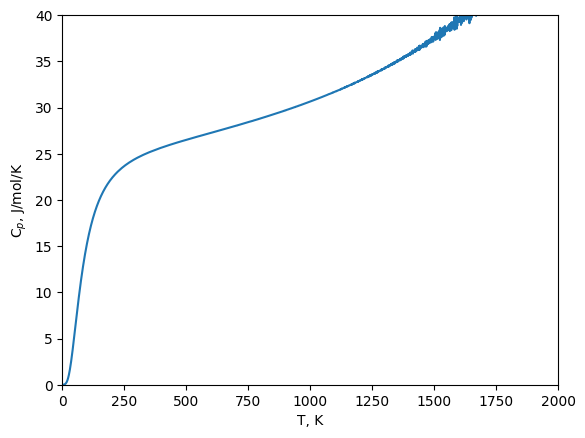

In [82]:
temp,Cps=tqha.value["Cp_QHA"]

plt.plot(temp,Cps)
plt.xlabel("T, K")
plt.ylabel("C$_p$, J/mol/K")
plt.xlim(0,2000)
plt.ylim(0,40)

oscillations at high temperatures are due to the numerical noise of the numerical derivatives.

One can use kernel smoothing like:

(0.0, 40.0)

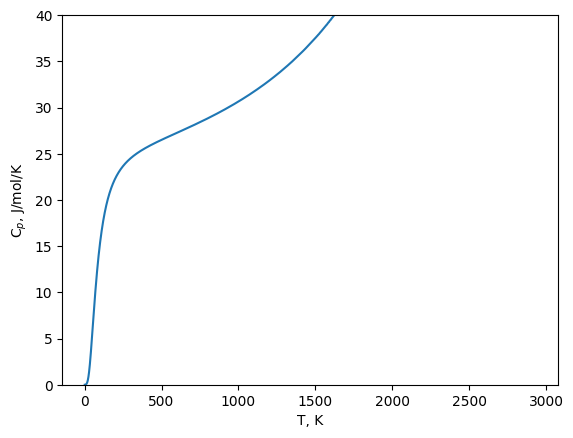

In [83]:
kernel=[1,3,5,3,1]
kernel=np.array(kernel)/np.sum(kernel)
Cps_smooth=np.convolve(Cps,kernel, 'same')    
for i in range(3):
    Cps_smooth=np.convolve(Cps_smooth,kernel, 'same')      

plt.plot(temp,Cps_smooth)
plt.xlabel("T, K")
plt.ylabel("C$_p$, J/mol/K")
plt.ylim(0,40)

Smoothing does not affect the low temperature heat capacity

(0.0, 40.0)

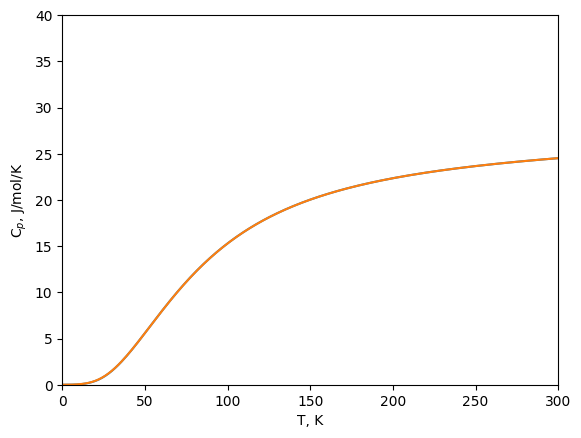

In [84]:
plt.plot(temp,Cps)
plt.plot(temp,Cps_smooth)
plt.xlabel("T, K")
plt.ylabel("C$_p$, J/mol/K")
plt.xlim(0,300)
plt.ylim(0,40)

### 2.2.9 Surface energy calculations (SurfaceEnergyCalculator)

Calculates the energy required to create a surface for various Miller orientations.

#### Available Parameters:

| Parameter | Type | Description | Default |
| :--- | :--- | :--- | :--- |
| `surface_orientation` | `str` | Miller indices (e.g., "100", "110", "111"). | `"100"` |
| `surface_name` | `str` | Identification label. | `"default"` |
| `optimizer` | `ASE Optimizer` | Optimizer for surface relaxation. | `FIRE` |
| `fmax` | `float` | Force convergence. | `0.01` |
| `fix_symmetry` | `bool` | Constrain symmetry during relaxation. | `True` |

Calculation of surface energies of bcc(100,110,111,112), fcc(100,110,111,112) and dia(100) structures

    Args:
         :param atoms: original ASE Atoms object
         :param surface_orientation: str, "100", "110", "111", "112"
         :param surface_name: str: i.e. "X100_Y010_Z001_6at" or "default"
         :param optimizer: optimizer class from ase.optimize, default = FIRE,
         :param fmax: fmax option for optimizer
            could be also BFGS, LBFGS, BFGSLineSearch, LBFGSLineSearch, MDMin, QuasiNewton, GoodOldQuasiNewton
         :param optimizer_kwargs: additional keyword arguments for optimizer class,
            f.e. optimizer_kwargs={"maxstep":0.05}
         :param fix_symmetry: bool, flag if use FixSymmetry constraint for optimization

One could check available surface prototypes:

In [85]:
SurfaceEnergyCalculator.available_surfaces(final_struct)

,structure_type,surface_orientation,surface_name
0,fcc,100,X100_Y010_Z001_10at
1,fcc,100,X100_Y010_Z001_42at
2,fcc,100,X100_Y010_Z001_6at
3,fcc,100,X110_Y-110_Z001_10at
4,fcc,100,X110_Y-110_Z001_1at
5,fcc,100,X110_Y-110_Z001_2at
6,fcc,100,X110_Y-110_Z001_3at
7,fcc,100,X110_Y-110_Z001_4at
8,fcc,100,X110_Y-110_Z001_5at
9,fcc,100,X110_Y-110_Z001_6at


In [86]:
surf_calculator=SurfaceEnergyCalculator(final_struct, 
                                        surface_orientation="100", 
                                        surface_name="X100_Y010_Z001_10at")

In [87]:
surf_calculator.calculate()

Available computed properties:

In [88]:
print(surf_calculator.value.keys())

odict_keys(['spgn', 'volume', 'structure_type', 'surface_name', 'surface_orientation', 'structure_name', 'surface_structure_energy', 'number_of_atoms', 'surface_area', 'max_force', 'ref_energy_per_atom', 'surface_energy', 'surface_energy(mJ/m^2)'])


In [89]:
surf_calculator.value

OrderedDict([('spgn', 225),
             ('volume', np.float64(11.565316606307942)),
             ('structure_type', 'fcc'),
             ('surface_name', 'X100_Y010_Z001_10at'),
             ('surface_orientation', '100'),
             ('structure_name', 'fcc_100surf_X100_Y010_Z001_10at'),
             ('surface_structure_energy', np.float64(2.7382789776264946)),
             ('number_of_atoms', 10),
             ('surface_area', np.float64(16.691058091194357)),
             ('max_force', np.float64(0.008540579585080366)),
             ('ref_energy_per_atom', np.float64(-0.007036491886934115)),
             ('surface_energy', np.float64(0.0841361848107635)),
             ('surface_energy(mJ/m^2)', np.float64(1348.0131258010906))])

In [90]:
print("Surface energy: ",surf_calculator.value["surface_energy"]," eV/Ang^2")

Surface energy:  0.0841361848107635  eV/Ang^2


### 2.2.10 [TEST MODE] Surface atom adsorption calculations (SurfaceAtomAdsorptionCurveCalculator)

Generates the energy profile as an atom approaches the surface.

#### Available Parameters:

| Parameter | Type | Description | Default |
| :--- | :--- | :--- | :--- |
| `z_min`, `z_max` | `float` | Range of distances from surface (Å). | `1, 9.1` |
| `dz` | `float` | Step size (Å). | `0.1` |
| `adsorption_position_atom_indices` | `tuple`| Indices of surface atoms to define lateral position. | `(0,)` |
| `elem` | `str` | Chemical identity of the adsorbate atom. | `None` |

Compute adsorption curve of the atom to the surface.

    :param surface: ASE atoms surface structure along XY direction
    :param adsorption_position_atom_indices: default=(0,),  tuple of indices of atoms on the top layer.
                 adsorption site would be AVERAGE position of those atoms
    :param z_min: default=1, min z-distance from the surface
    :param z_max: default=9.1, max z-distance from the surface
    :param dz: default=0.1, step in z
    :param surface_supercell_size: default=(2, 3), supercell size along X,Y of original *atoms* surface
    :param adsorption_energy_alignment: default="last", adsorption energy alignment:
                "last" - adsorption atom at z_max has zero energy

Get optimized structure from the previos `surface calculator`

In [91]:
surface_structure = surf_calculator._structure_dict['SURFACE___atomic']

In [92]:
surface_structure.calc = calc

Create surface atom adsorption calculator:

In [93]:
surface_atom_adsorption_calculator = SurfaceAtomAdsorptionCurveCalculator(surface_structure,
                                                                         adsorption_position_atom_indices=(0,1))

In [94]:
surface_atom_adsorption_calculator.calculate()

In [95]:
surface_atom_adsorption_calculator.value.keys()

odict_keys(['surface_supercell_size', 'z_shift', 'adsorption_position_atom_indices', 'adsorption_energy_alignment', 'top_atoms_positions', 'adsorption_position', 'raw_adsorption_data', 'adsorption_energies'])

In [96]:
top_atoms_positions=np.array(surface_atom_adsorption_calculator.value["top_atoms_positions"])
adsorption_positions = surface_atom_adsorption_calculator.value["adsorption_position"]

Adsorption site is between atoms with indices 0 and 1 (adsorption_position_atom_indices=(0,1)):

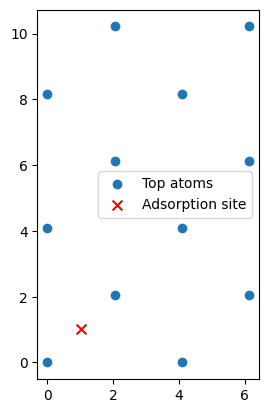

In [97]:
plt.scatter(top_atoms_positions[:,0], top_atoms_positions[:,1], 
            label="Top atoms")
plt.scatter([adsorption_positions[0]], [adsorption_positions[1]], marker="x", color="red",s=50,
            label="Adsorption site"
           )
plt.gca().set_aspect(1)
plt.legend()

(-3.0, 3.0)

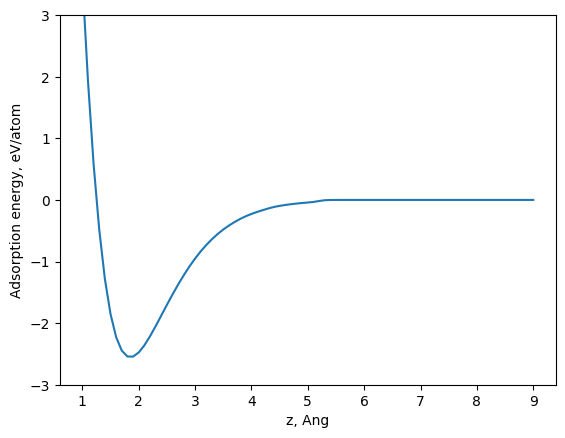

In [98]:
plt.plot(surface_atom_adsorption_calculator.value["z_shift"], 
         surface_atom_adsorption_calculator.value["adsorption_energies"])
plt.xlabel("z, Ang")
plt.ylabel("Adsorption energy, eV/atom")
plt.ylim(-3,3)

### 2.2.11 [TEST MODE] Surface decohesion calculations (SurfaceDecohesionCalculator)

Evaluates the universal binding energy curve (UBER) for slab decohesion.

#### Available Parameters:

| Parameter | Type | Description | Default |
| :--- | :--- | :--- | :--- |
| `zmin`, `zmax` | `float` | Separation range (Å). | `-0.1, 7.3` |
| `dz` | `float` | Step size. | `0.1` |
| `surface_orientation`| `str` | Orientation of the cleavage plane. | (Required) |
| `optimizer` | `ASE Optimizer` | Optimizer for relaxation. | `FIRE` |

Compute surface decohesion energy curve

    :param atoms: original ASE Atoms object
    :param surface_orientation: str, "100", "110", "111", "112"
    :param surface_name: str: i.e. "X100_Y010_Z001_6at" or "default"
    :param optimizer: optimizer class from ase.optimize, default = FIRE,
    :param fmax: fmax option for optimizer
    could be also BFGS, LBFGS, BFGSLineSearch, LBFGSLineSearch, MDMin, QuasiNewton, GoodOldQuasiNewton
    :param optimizer_kwargs: additional keyword arguments for optimizer class,
    f.e. optimizer_kwargs={"maxstep":0.05}
    :param fix_symmetry: bool, flag if use FixSymmetry constraint for optimization
    :param z_min: default=-0.1, min z-distance  between surfaces, negative value corresponds to compression
    :param z_max: default=7.3, max z-distance between the surfaces
    :param dz: default=0.1, step in z

In [99]:
surface_decohesion=SurfaceDecohesionCalculator(final_struct, 
                            surface_orientation="111", 
                            surface_name="X121_Y-101_Z1-11_6at")

In [100]:
surface_decohesion.calculate()

In [101]:
surface_decohesion.value.keys()

odict_keys(['spgn', 'volume', 'zmin', 'zmax', 'dz', 'structure_type', 'surface_name', 'surface_orientation', 'structure_name', 'surface_structure_energy', 'number_of_atoms', 'surface_area', 'max_force', 'ref_energy_per_atom', 'surface_energy', 'surface_energy(mJ/m^2)', 'surface_bulk_energy', 'z', 'e_surf', 'e_surf_relax', 'e_surf(mJ/m^2)', 'e_surf_relax(mJ/m^2)'])

Text(0, 0.5, 'Surface decohesion energy, eV/Ang^2')

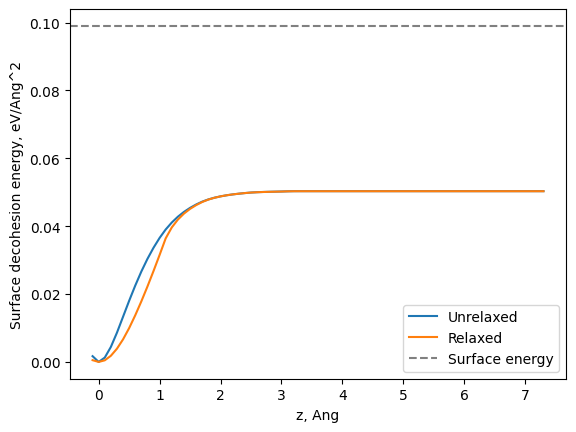

In [102]:
plt.plot(surface_decohesion.value["z"],surface_decohesion.value["e_surf"], label="Unrelaxed")
plt.plot(surface_decohesion.value["z"],surface_decohesion.value["e_surf_relax"], label="Relaxed")
plt.axhline(surface_decohesion.value["surface_energy"], label="Surface energy",color="gray",ls="--")
plt.legend()
plt.xlabel("z, Ang")
plt.ylabel("Surface decohesion energy, eV/Ang^2")

### 2.2.12 Stacking fault energies (StackingFaultCalculator)

Calculates specific stacking fault energies for FCC crystals using optimized supercells.

#### Available Parameters:

| Parameter | Type | Description | Default |
| :--- | :--- | :--- | :--- |
| `stacking_fault_types` | `str` or `list` | Types to calculate ("all" or list like ["ISF", "ESF"]). | `"all"` |
| `optimizer` | `ASE Optimizer` | Optimizer class (e.g., FIRE, BFGS). | `FIRE` |
| `fmax` | `float` | Force convergence (eV/Å). | `0.01` |
| `optimizer_kwargs` | `dict` | Additional settings for the optimizer. | `None` |
| `fix_symmetry` | `bool` | Use FixSymmetry constraint for optimization. | `True` |

Calculation stacking fault energies in FCC

Args:

         :param atoms: original ASE Atoms object
         :param stacking_fault_type: str: "all", or any combination of "ESF", "ISF", "MAX", "MIDDLE", "TWIN"
         :param optimizer: optimizer class from ase.optimize, default = FIRE,
            could be also BFGS, LBFGS, BFGSLineSearch, LBFGSLineSearch, MDMin, QuasiNewton, GoodOldQuasiNewton
         :param fmax: fmax option for optimizer
         :param optimizer_kwargs: additional keyword arguments for optimizer class,
            f.e. optimizer_kwargs={"maxstep":0.05}
         :param fix_symmetry: bool, flag if use FixSymmetry constraint for optimization

In [103]:
stacking_fault_calculator = StackingFaultCalculator(final_struct,stacking_fault_types="all")

In [104]:
stacking_fault_calculator.calculate()

Reading /Users/lysogy36/micromamba/envs/grace/lib/python3.11/site-packages/amstools/resources/data/structures/Stacking_faults/fcc/fcc_ESF_prim_12at.cfg
Reading /Users/lysogy36/micromamba/envs/grace/lib/python3.11/site-packages/amstools/resources/data/structures/Stacking_faults/fcc/fcc_ISF_prim_12at.cfg
Reading /Users/lysogy36/micromamba/envs/grace/lib/python3.11/site-packages/amstools/resources/data/structures/Stacking_faults/fcc/fcc_MAX_prim_12at.cfg
Reading /Users/lysogy36/micromamba/envs/grace/lib/python3.11/site-packages/amstools/resources/data/structures/Stacking_faults/fcc/fcc_MIDDLE_prim_12at.cfg
Reading /Users/lysogy36/micromamba/envs/grace/lib/python3.11/site-packages/amstools/resources/data/structures/Stacking_faults/fcc/fcc_TWIN_prim_12at.cfg
Reading /Users/lysogy36/micromamba/envs/grace/lib/python3.11/site-packages/amstools/resources/data/structures/Stacking_faults/fcc/fcc_IDEAL_prim_12at.cfg
Reading /Users/lysogy36/micromamba/envs/grace/lib/python3.11/site-packages/amstool

In [105]:
stacking_fault_calculator.value.keys()

odict_keys(['spgn', 'structure_type', 'lattice_param', 'd0', 'stacking_fault_types', 'structure_names', 'sf_area', 'raw_data', 'stacking_fault_energy', 'stacking_fault_energy(mJ/m^2)'])

In [106]:
stacking_fault_calculator.value

OrderedDict([('spgn', 225),
             ('structure_type', 'fcc'),
             ('lattice_param', np.float64(3.5898186200427484)),
             ('d0', np.float64(2.888862932988891)),
             ('stacking_fault_types',
              ['ESF', 'ISF', 'MAX', 'MIDDLE', 'TWIN', 'IDEAL']),
             ('structure_names',
              ['fcc_ESF',
               'fcc_ISF',
               'fcc_MAX',
               'fcc_MIDDLE',
               'fcc_TWIN',
               'fcc_IDEAL']),
             ('sf_area', np.float64(7.227440129924914)),
             ('raw_data',
              {'fcc_ESF___static': {'energy': np.float64(7.04454179622284),
                'max_force': np.float64(1.0964672440406602)},
               'fcc_ESF___atomic': {'energy': np.float64(3.1500822933685653),
                'max_force': np.float64(0.009251247422803033)},
               'fcc_ISF___static': {'energy': np.float64(7.044541793432974),
                'max_force': np.float64(1.096467244040662)},
               

In [107]:
import pandas as pd

In [108]:
pd.DataFrame(stacking_fault_calculator.value["stacking_fault_energy(mJ/m^2)"]).T

,static,atomic
fcc_ESF,4.410999,-14.273008
fcc_ISF,4.410993,-13.686010
fcc_MAX,161.382915,1823.252220
fcc_MIDDLE,42.291539,1815.503806
fcc_TWIN,2.205497,-8.625799
fcc_IDEAL,0.000000,0.000000


### 2.2.13 Generalized Stacking Fault Energy (Gamma Surface)

Calculates the energy penalty for shifting one part of a crystal relative to another along a specific plane.

#### Available Parameters:

| Parameter | Type | Description | Default |
| :--- | :--- | :--- | :--- |
| `shift_surface` | `tuple` | (Surface) Max shift (multiples of basis vectors). | `(1, 1)` |
| `num_of_point_per_line` | `int` | (Surface) Grid density. | `10` |
| `shift_vector` | `tuple` | (Line) Directional shift vector. | `(0, 1)` |
| `num_of_point` | `int` | (Line) Number of sampling points. | `10` |
| `optimizer` | `str` | Name of the optimizer (e.g., "FIRE", "BFGS"). | `"FIRE"` |
| `fmax` | `float` | Force convergence (eV/Å). | `1e-2` |
| `z_cut_level` | `float` | Fractional coordinate for the fault plane. | `0.5` |
| `auto_constraint` | `bool` | Restrict relaxation to perpendicular direction (Z). | `True` |

In [109]:
from ase.lattice.cubic import FaceCenteredCubic

from ase.constraints import FixedLine

In [110]:
a0 = (final_struct.get_volume()*4)**(1/3.)

create a FCC block

In [111]:
block = FaceCenteredCubic(
    directions=[[-1,1,0], [1,1,2], [1,1,-1]],
    size=(1,1,8), 
    symbol="Cu", 
    pbc=(1,1,1),
    latticeconstant=a0)
block.calc = calc

Apply constraint : atom must relax along z

In [112]:
myconstraints=[]
for i in [atom.index for atom in block]:
    myconstraints.append(FixedLine(i,(0,0,1)))
block.set_constraint(myconstraints)

#### Gamma surface

In [113]:
gsf=GammaSurfaceCalculator(block, shift_surface=[1,1], 
                           num_of_point_per_line=5,
                           fmax=1E-2,
                           z_cut_level=0.5)

In [114]:
gsf.calculate(verbose=True)

2026-03-01 12:52:58,373 - root - INFO - Processing task/structure #1/25: n_0_m_0


      Step     Time          Energy          fmax
FIRE:    0 12:52:58       -0.337752        0.000000


2026-03-01 12:52:58,387 - root - INFO - Processing task/structure #2/25: n_0_m_1


      Step     Time          Energy          fmax
FIRE:    0 12:52:58       -0.223919        0.265305
FIRE:    1 12:52:58       -0.226525        0.225865
FIRE:    2 12:52:58       -0.230272        0.154747
FIRE:    3 12:52:58       -0.233201        0.065557
FIRE:    4 12:52:58       -0.234160        0.074383
FIRE:    5 12:52:58       -0.234220        0.072556
FIRE:    6 12:52:58       -0.234335        0.068970
FIRE:    7 12:52:58       -0.234492        0.063767
FIRE:    8 12:52:58       -0.234675        0.057154
FIRE:    9 12:52:58       -0.234868        0.049410
FIRE:   10 12:52:58       -0.235056        0.040891
FIRE:   11 12:52:58       -0.235228        0.032034
FIRE:   12 12:52:58       -0.235397        0.023702
FIRE:   13 12:52:58       -0.235559        0.025218
FIRE:   14 12:52:58       -0.235723        0.026613
FIRE:   15 12:52:58       -0.235899        0.026098
FIRE:   16 12:52:58       -0.236095        0.021334
FIRE:   17 12:52:58       -0.236293        0.016795
FIRE:   18 12:

2026-03-01 12:52:58,559 - root - INFO - Processing task/structure #3/25: n_0_m_2


...

      Step     Time          Energy          fmax
FIRE:    0 12:53:03       -0.223919        0.265305
FIRE:    1 12:53:03       -0.226525        0.225865
FIRE:    2 12:53:03       -0.230272        0.154747
FIRE:    3 12:53:03       -0.233201        0.065557
FIRE:    4 12:53:03       -0.234160        0.074383
FIRE:    5 12:53:03       -0.234220        0.072556
FIRE:    6 12:53:03       -0.234335        0.068970
FIRE:    7 12:53:03       -0.234492        0.063767
FIRE:    8 12:53:03       -0.234675        0.057154
FIRE:    9 12:53:03       -0.234868        0.049410
FIRE:   10 12:53:03       -0.235056        0.040891
FIRE:   11 12:53:03       -0.235228        0.032034
FIRE:   12 12:53:03       -0.235397        0.023702
FIRE:   13 12:53:03       -0.235559        0.025218
FIRE:   14 12:53:03       -0.235723        0.026613
FIRE:   15 12:53:03       -0.235899        0.026098
FIRE:   16 12:53:03       -0.236095        0.021334
FIRE:   17 12:53:03       -0.236293        0.016795
FIRE:   18 12:

2026-03-01 12:53:03,555 - root - INFO - Processing task/structure #24/25: n_4_m_3


      Step     Time          Energy          fmax
FIRE:    0 12:53:03        0.489388        1.932365
FIRE:    1 12:53:03        0.361380        1.391064
FIRE:    2 12:53:03        0.229530        0.609465
FIRE:    3 12:53:03        0.186509        0.417657
FIRE:    4 12:53:03        0.184671        0.405405
FIRE:    5 12:53:03        0.181234        0.381506
FIRE:    6 12:53:03        0.176631        0.347155
FIRE:    7 12:53:03        0.171399        0.304095
FIRE:    8 12:53:03        0.166077        0.254585
FIRE:    9 12:53:03        0.161088        0.201414
FIRE:   10 12:53:03        0.156658        0.147928
FIRE:   11 12:53:03        0.152408        0.127939
FIRE:   12 12:53:03        0.148255        0.142561
FIRE:   13 12:53:03        0.143955        0.140391
FIRE:   14 12:53:03        0.139335        0.131456
FIRE:   15 12:53:03        0.134610        0.108176
FIRE:   16 12:53:03        0.130489        0.091219
FIRE:   17 12:53:03        0.127691        0.099636
FIRE:   18 12:

2026-03-01 12:53:03,801 - root - INFO - Processing task/structure #25/25: n_4_m_4


      Step     Time          Energy          fmax
FIRE:    0 12:53:03        0.189928        1.228921
FIRE:    1 12:53:03        0.136435        0.950687
FIRE:    2 12:53:03        0.072975        0.508042
FIRE:    3 12:53:03        0.041647        0.263301
FIRE:    4 12:53:03        0.045487        0.325853
FIRE:    5 12:53:03        0.043562        0.313738
FIRE:    6 12:53:03        0.040037        0.290209
FIRE:    7 12:53:03        0.035497        0.256620
FIRE:    8 12:53:03        0.030674        0.214880
FIRE:    9 12:53:03        0.026302        0.167365
FIRE:   10 12:53:03        0.022961        0.116919
FIRE:   11 12:53:03        0.020918        0.096078
FIRE:   12 12:53:03        0.019945        0.102649
FIRE:   13 12:53:03        0.019611        0.152232
FIRE:   14 12:53:03        0.019486        0.150007
FIRE:   15 12:53:03        0.019242        0.145598
FIRE:   16 12:53:03        0.018891        0.139089
FIRE:   17 12:53:03        0.018451        0.130609
FIRE:   18 12:

In [115]:
gsf.value

{'shift_surface': [1, 1],
 'num_of_point_per_line': 5,
 'optimizer': 'FIRE',
 'fmax': 0.01,
 'z_cut_level': 0.5,
 'real_shift_surface': [np.float64(2.5383850894619617),
  np.float64(4.3966119441233875)],
 'shift': array([[0.        , 0.        , 0.        ],
        [0.        , 0.87932239, 0.        ],
        [0.        , 1.75864478, 0.        ],
        [0.        , 2.63796717, 0.        ],
        [0.        , 3.51728956, 0.        ],
        [0.50767702, 0.        , 0.        ],
        [0.50767702, 0.87932239, 0.        ],
        [0.50767702, 1.75864478, 0.        ],
        [0.50767702, 2.63796717, 0.        ],
        [0.50767702, 3.51728956, 0.        ],
        [1.01535404, 0.        , 0.        ],
        [1.01535404, 0.87932239, 0.        ],
        [1.01535404, 1.75864478, 0.        ],
        [1.01535404, 2.63796717, 0.        ],
        [1.01535404, 3.51728956, 0.        ],
        [1.52303105, 0.        , 0.        ],
        [1.52303105, 0.87932239, 0.        ],
     

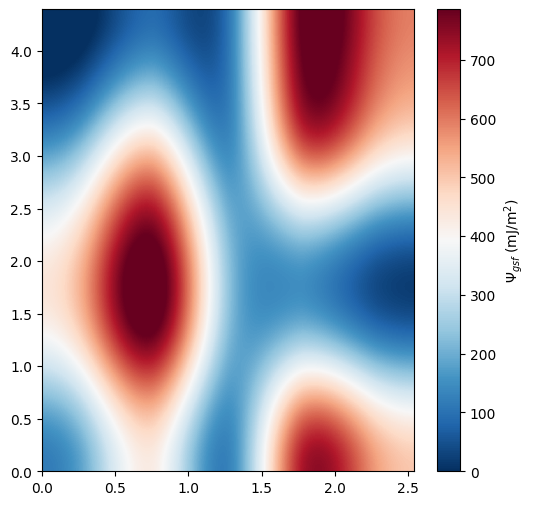

In [116]:
plt.figure(figsize=(6,6))
E=gsf.value['energy_map(mJ/m2)']-gsf.value['energy_map(mJ/m2)'][0][0]
a=np.sqrt(2.)*a0*0.5
b=np.sqrt(6.)*a0*0.5
im=plt.imshow(E,cmap=plt.cm.RdBu_r, interpolation='spline36',
              extent=[0,a,0,b], aspect='auto')
plt.colorbar(im,label='$\Psi_{gsf}$ (mJ/m$^2$)')

#### Gamma line

In [117]:
gln=GammaLineCalculator(block,
                        shift_vector=[0,1.0],
                        num_of_point=11,
                        fmax=1E-2,
                        z_cut_level=0.5)

In [118]:
gln.calculate(verbose=True)

2026-03-01 12:53:04,274 - root - INFO - Processing task/structure #1/11: X_0_Y_1_0_n_0


      Step     Time          Energy          fmax
FIRE:    0 12:53:04       -0.337752        0.000000


2026-03-01 12:53:04,325 - root - INFO - Processing task/structure #2/11: X_0_Y_1_0_n_1


      Step     Time          Energy          fmax
FIRE:    0 12:53:04       -0.260167        0.172459
FIRE:    1 12:53:04       -0.261271        0.147967
FIRE:    2 12:53:04       -0.262883        0.103339
FIRE:    3 12:53:04       -0.264179        0.046430
FIRE:    4 12:53:04       -0.264638        0.047976
FIRE:    5 12:53:04       -0.264662        0.046849
FIRE:    6 12:53:04       -0.264708        0.044634
FIRE:    7 12:53:04       -0.264772        0.041416
FIRE:    8 12:53:04       -0.264846        0.037320
FIRE:    9 12:53:04       -0.264926        0.032510
FIRE:   10 12:53:04       -0.265006        0.027201
FIRE:   11 12:53:04       -0.265080        0.021654
FIRE:   12 12:53:04       -0.265154        0.015606
FIRE:   13 12:53:04       -0.265227        0.016192
FIRE:   14 12:53:04       -0.265300        0.016633
FIRE:   15 12:53:04       -0.265378        0.016000
FIRE:   16 12:53:04       -0.265461        0.014019
FIRE:   17 12:53:04       -0.265544        0.010693
FIRE:   18 12:

2026-03-01 12:53:04,501 - root - INFO - Processing task/structure #3/11: X_0_Y_1_0_n_2


...

      Step     Time          Energy          fmax
FIRE:    0 12:53:05        0.944761        3.029232
FIRE:    1 12:53:05        0.645812        1.943219
FIRE:    2 12:53:05        0.398939        0.594317
FIRE:    3 12:53:05        0.370484        0.654045
FIRE:    4 12:53:05        0.364435        0.628183
FIRE:    5 12:53:05        0.353470        0.578227
FIRE:    6 12:53:05        0.339596        0.507526
FIRE:    7 12:53:05        0.325222        0.420699
FIRE:    8 12:53:05        0.312588        0.323344
FIRE:    9 12:53:05        0.303188        0.222141
FIRE:   10 12:53:05        0.297263        0.174272
FIRE:   11 12:53:05        0.293414        0.243457
FIRE:   12 12:53:05        0.289980        0.294725
FIRE:   13 12:53:05        0.284901        0.303456
FIRE:   14 12:53:05        0.277013        0.264669
FIRE:   15 12:53:05        0.267156        0.179863
FIRE:   16 12:53:05        0.258376        0.134268
FIRE:   17 12:53:05        0.254026        0.136866
FIRE:   18 12:

2026-03-01 12:53:05,782 - root - INFO - Processing task/structure #10/11: X_0_Y_1_0_n_9


      Step     Time          Energy          fmax
FIRE:    0 12:53:05        0.359304        1.622630
FIRE:    1 12:53:05        0.267763        1.205239
FIRE:    2 12:53:05        0.167570        0.576623
FIRE:    3 12:53:05        0.128079        0.349261
FIRE:    4 12:53:05        0.141050        0.436891
FIRE:    5 12:53:05        0.137390        0.414529
FIRE:    6 12:53:05        0.130726        0.372887
FIRE:    7 12:53:05        0.122229        0.324884
FIRE:    8 12:53:05        0.113361        0.265748
FIRE:    9 12:53:05        0.105565        0.199165
FIRE:   10 12:53:05        0.099965        0.129438
FIRE:   11 12:53:05        0.097035        0.124356
FIRE:   12 12:53:05        0.096303        0.144603
FIRE:   13 12:53:05        0.096188        0.142878
FIRE:   14 12:53:05        0.095962        0.139456
FIRE:   15 12:53:05        0.095634        0.134394
FIRE:   16 12:53:05        0.095214        0.127781
FIRE:   17 12:53:05        0.094716        0.119737
FIRE:   18 12:

2026-03-01 12:53:06,051 - root - INFO - Processing task/structure #11/11: X_0_Y_1_0_n_10


      Step     Time          Energy          fmax
FIRE:    0 12:53:06       -0.169204        0.384918
FIRE:    1 12:53:06       -0.174660        0.323908
FIRE:    2 12:53:06       -0.182325        0.215492
FIRE:    3 12:53:06       -0.188015        0.082580
FIRE:    4 12:53:06       -0.189557        0.107702
FIRE:    5 12:53:06       -0.189693        0.104866
FIRE:    6 12:53:06       -0.189949        0.099309
FIRE:    7 12:53:06       -0.190295        0.091260
FIRE:    8 12:53:06       -0.190691        0.081060
FIRE:    9 12:53:06       -0.191099        0.069158
FIRE:   10 12:53:06       -0.191482        0.056125
FIRE:   11 12:53:06       -0.191818        0.042674
FIRE:   12 12:53:06       -0.192130        0.034288
FIRE:   13 12:53:06       -0.192418        0.036415
FIRE:   14 12:53:06       -0.192709        0.041778
FIRE:   15 12:53:06       -0.193037        0.041528
FIRE:   16 12:53:06       -0.193419        0.034497
FIRE:   17 12:53:06       -0.193820        0.024228
FIRE:   18 12:

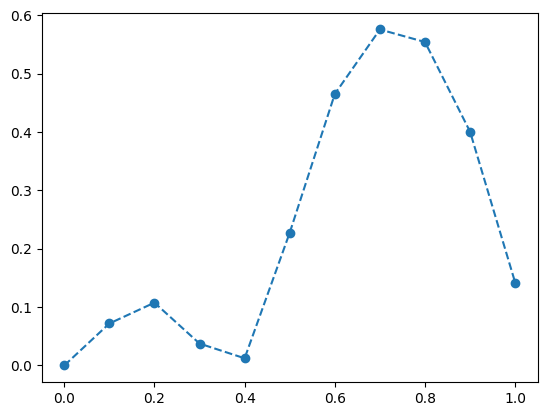

In [119]:
S=gln.value['shift']/gln.value['shift'][-1]
E=gln.value['energy']-gln.value['energy'][0] 
plt.plot(S,E,'o--')